# Phase 1 main experiment (part 1e / ARM B): the drift-regime conditions test

**What this decides.** The whole "conditions of validity" thesis rests on H1:
explanation-space localization beats cheap label-free statistics under *concept*
drift but not under *distributional* drift. So far that is confounded -- on real
data (distributional) we had no trustworthy ground truth and explanations were
redundant; on the synthetic pilot (concept) we had ground truth and explanations
won. Drift type and ground-truth availability moved together, so we cannot yet
attribute the difference to drift type.

**How this breaks the confound.** A 2x2 crossover on **real CICIDS feature
vectors** with a **synthetic label rule**, so the true drifted features are known
in *both* arms (ground-truth availability held constant). The only thing that
differs between arms is the drift mechanism:

- **Distributional arm:** keep the labeling rule fixed; shift the input marginals
  of the relevant features. P(X) moves, P(y|X) stable. A label-free KS test can
  see it.
- **Concept arm:** keep the input distribution identical; swap which features the
  label depends on (S1 -> S2). P(X) stable, P(y|X) moves. KS is blind by
  construction; only a model-relative signal can localize it.

Each method (KS, aux-SHAP) tries to recover the known drifted set in each arm.

**The prediction that is the thesis:** KS recovers the distributional drift but
collapses to chance on concept drift; aux-SHAP recovers both -- so explanations
are *necessary* only in the concept regime. If that crossover appears with ground
truth known throughout, drift type (not GT availability) is the governing
variable, and the conditions claim is earned.

**Construction validity is checked first.** Before the verdict we confirm the
concept arm's P(X) really is stable (KS near chance) and the labels are learnable
(aux recall high). A leak would let distributional drift sneak into the concept
arm and fake a result; these checks catch that.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    jaccard, random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07e_regime_testbed.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)
print(f'{N_FEATURES} real features available for the testbed.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'ks': '#0072B2', 'aux_shap': '#E69F00', 'dual_gain': '#009E73', 'random': '#000000'}
METHOD_LABEL = {'ks': 'KS (label-free)', 'aux_shap': 'Aux-SHAP', 'dual_gain': 'Dual-gain', 'random': 'Random'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07e_drift_regime_testbed'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Mounted at /content/drive
82 real features available for the testbed.
Setup complete.


## 2. D021 -- the conditions test, H1, and the pre-registered gate

In [2]:
log_decision(
    decision_id='D021',
    decision=(
        'Build a semi-synthetic 2x2 crossover on REAL CICIDS feature vectors with '
        'a synthetic label rule, so the true drifted features are KNOWN in both '
        'arms (ground-truth availability held constant). Distributional arm: fixed '
        'rule, shift the input marginals of the relevant features (P(X) moves, '
        'P(y|X) stable; drifted GT = the shifted features). Concept arm: identical '
        'input distribution, swap relevant features S1->S2 (P(X) stable, P(y|X) '
        'moves; drifted GT = the newly-relevant features S2). Recover the known '
        'GT with KS (label-free) and aux-SHAP in each arm. '
        'Pre-registered hypothesis H1: explanations beat cheap statistics under '
        'concept drift but not distributional. Gate (committed before execution): '
        'H1-SUPPORTED iff (validity) concept-arm KS precision@10 <= 0.30 i.e. near '
        'chance, confirming P(X) stable; AND (concept pole) aux-SHAP precision@10 '
        '>= 0.50 and aux-SHAP - KS >= 0.20 in the concept arm; AND (distributional '
        'pole) KS precision@10 >= 0.50 and KS >= aux-SHAP - 0.10. '
        'Falsifiers: F-a (concept pole fails: SHAP does not localize even with '
        'known GT) -> narrow claim to idealized settings; F-b (validity fails: KS '
        'not near chance in concept) -> construction leaked input drift, INVALID; '
        'F-c (confound) -> addressed by design since GT is known in both arms.'
    ),
    rationale=(
        'On real data, drift type and ground-truth availability were confounded. '
        'A known-GT semi-synthetic testbed on real (correlated) feature vectors '
        'isolates drift type while keeping the realistic correlation structure '
        'that destabilised importance on real data, so SHAP gets a fair but not '
        'rigged test. The crossover (KS wins distributional, SHAP necessary for '
        'concept) is the conditions result; the validity checks prevent a leak '
        'from faking it.'
    ),
    alternatives=(
        'Force a concept arm from a UNSW family-holdout split (rejected: that is '
        'distributional drift mislabelled). Pure synthetic (rejected: loses the '
        'real correlation structure and re-introduces the synthetic-vs-real gap).'
    ),
)


[DECISION LOGGED] D021


## 3. Configuration

In [3]:
set_global_seed(42)

N_POOL = 40000          # real feature vectors drawn for the testbed
ARM_N = 8000            # rows per side (pre / post) within an arm
GT_SIZE = 15            # relevant / drifted feature-set size
REL_SIZE = GT_SIZE
K_PRIMARY = 10
SHAP_SAMPLE = 1500
DRIFT_DELTA = 1.5       # additive marginal shift (in z-units) on the distributional arm
SEEDS = [42, 1, 7]

ARMS = ['distributional', 'concept']
METHODS = ['ks', 'aux_shap', 'dual_gain', 'random']
CHANCE = random_precision_expectation(GT_SIZE, N_FEATURES)

# Pre-registered gate thresholds (see D021):
VALID_KS_CONCEPT_MAX = 0.30   # concept-arm KS must be near chance -> P(X) stable
SHAP_CONCEPT_MIN = 0.50       # SHAP must clearly localize in the concept arm
CONCEPT_MARGIN = 0.20         # SHAP - KS in the concept arm
KS_DIST_MIN = 0.50            # KS must localize in the distributional arm
KS_COMPETITIVE_TOL = 0.10     # KS >= SHAP - tol in the distributional arm

print(f'Chance precision@{K_PRIMARY} = {CHANCE:.3f}  |  GT_SIZE={GT_SIZE} of {N_FEATURES}')
print(f'H1 supported iff: concept KS<= {VALID_KS_CONCEPT_MAX} (valid); concept SHAP>= {SHAP_CONCEPT_MIN} '
      f'& SHAP-KS>= {CONCEPT_MARGIN}; distributional KS>= {KS_DIST_MIN} & KS>= SHAP-{KS_COMPETITIVE_TOL}.')


Chance precision@10 = 0.183  |  GT_SIZE=15 of 82
H1 supported iff: concept KS<= 0.3 (valid); concept SHAP>= 0.5 & SHAP-KS>= 0.2; distributional KS>= 0.5 & KS>= SHAP-0.1.


## 4. Build the real feature pool (z-scored)

Real CICIDS feature vectors give the realistic, correlated input distribution.
We discard the real labels -- only the feature geometry is used; labels come from
the synthetic rule. Standardising lets the linear rule behave across features.


In [4]:
X_raw, _, _ = load_cicids2017(day='monday')
X_raw = X_raw.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
idx = np.random.default_rng(42).choice(len(X_raw), size=min(N_POOL, len(X_raw)), replace=False)
Xp = X_raw.iloc[idx].to_numpy(dtype=float)
mu, sd = Xp.mean(0), Xp.std(0)
sd[sd == 0] = 1.0
POOL = (Xp - mu) / sd      # z-scored real feature vectors, shape (N_POOL, N_FEATURES)
print(f'Feature pool: {POOL.shape}  (z-scored real CICIDS vectors)')


Feature pool: (40000, 82)  (z-scored real CICIDS vectors)


## 5. Semi-synthetic generators

A linear rule over a chosen relevant set defines the labels; the median score is
the threshold so classes are balanced. In the distributional arm the rule's
weights over the shifted set are mean-centred, so a uniform additive marginal
shift leaves the score (and the labels) unchanged -- a clean covariate shift with
P(y|X) and class balance preserved, only P(X) moving. In the concept arm the
input pool is shared (P(X) identical) and only the relevant set changes.


In [5]:
def _weights(rel_idx, rng, center=False):
    w = np.zeros(N_FEATURES)
    v = rng.normal(size=len(rel_idx))
    if center:
        v = v - v.mean()      # so a uniform additive shift on rel_idx cancels in the score
    w[rel_idx] = v
    return w

def _labels(X, w):
    s = X @ w
    return (s > np.median(s)).astype(int)

def build_arm(arm, seed):
    """Return (X_pre, y_pre, X_post, y_post, gt_set). Real feature vectors,
    synthetic labels, known drifted ground truth."""
    rng = np.random.default_rng(seed)
    rows = rng.permutation(len(POOL))
    pre_rows, post_rows = rows[:ARM_N], rows[ARM_N:2 * ARM_N]
    X_pre, X_post = POOL[pre_rows].copy(), POOL[post_rows].copy()

    if arm == 'distributional':
        S = rng.choice(N_FEATURES, size=REL_SIZE, replace=False)
        w = _weights(S, rng, center=True)           # centred -> shift won't move labels
        y_pre = _labels(X_pre, w)
        X_post[:, S] += DRIFT_DELTA                  # marginal shift on the relevant set
        y_post = _labels(X_post, w)                  # same rule; balance preserved
        gt = set(int(i) for i in S)
    else:  # concept
        all_idx = rng.permutation(N_FEATURES)
        S1 = all_idx[:REL_SIZE]
        S2 = all_idx[REL_SIZE:2 * REL_SIZE]          # disjoint from S1
        w1, w2 = _weights(S1, rng), _weights(S2, rng)
        y_pre = _labels(X_pre, w1)
        y_post = _labels(X_post, w2)                 # relevance swap; X distribution unchanged
        gt = set(int(i) for i in S2)
    return X_pre, y_pre, X_post, y_post, gt

print('Generators defined.')


Generators defined.


## 6. Run both arms (with construction-validity diagnostics)

For each arm and seed: build the data, train a frozen pre-model and a post-drift
aux model, compute KS / aux-SHAP / dual-gain / random localization scores, and
score precision@K against the known drifted set. We also record the diagnostics
that decide whether the construction is sound.


In [6]:
rows, diag = [], []
t0 = time.time()
for arm in ARMS:
    for seed in SEEDS:
        X_pre, y_pre, X_post, y_post, gt = build_arm(arm, seed)

        # split post for an aux model + held-out SHAP/eval sample
        tr, ev = train_test_split(np.arange(len(y_post)), train_size=0.7,
                                  stratify=y_post if len(np.unique(y_post)) > 1 else None,
                                  random_state=seed)
        pre_model = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_pre, y_pre)
        aux = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_post[tr], y_post[tr])

        aux_rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
                   if len(np.unique(y_post[ev])) > 1 else float('nan'))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)
        Xs = X_post[sidx]

        ks = ks_drift_scores(X_pre, X_post)
        imp_pre = shap_importance(pre_model, Xs)
        imp_aux = shap_importance(aux, Xs)
        scores = {
            'ks': ks,
            'aux_shap': imp_aux,
            'dual_gain': np.clip(imp_aux - imp_pre, 0, None),
            'random': np.random.default_rng(seed).random(N_FEATURES),
        }
        for m, sc in scores.items():
            rows.append({'arm': arm, 'seed': seed, 'method': m,
                         'precision': precision_at_k(sc, gt, K_PRIMARY)})

        diag.append({'arm': arm, 'seed': seed,
                     'balance_pre': float(np.mean(y_pre)), 'balance_post': float(np.mean(y_post)),
                     'aux_recall': aux_rec, 'ks_max': float(np.max(ks)),
                     'ks_on_gt_topk': precision_at_k(ks, gt, K_PRIMARY)})
    print(f'{arm:<15} done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows)
diag_df = pd.DataFrame(diag)
res.to_csv(TABLES / '07e_regime_precision_raw.csv', index=False)
diag_df.to_csv(TABLES / '07e_construction_diagnostics.csv', index=False)

print('\nConstruction-validity diagnostics (mean over seeds):')
print(diag_df.groupby('arm')[['balance_pre', 'balance_post', 'aux_recall', 'ks_max']]
      .mean().round(3).to_string())
print('\n(Concept arm: balance ~0.5, aux_recall high => labels learnable;')
print(' ks_max small => P(X) stable. Distributional arm: ks_max large => shift visible.)')


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


distributional  done  (69s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


concept         done  (134s)

Construction-validity diagnostics (mean over seeds):
                balance_pre  balance_post  aux_recall  ks_max
arm                                                          
concept                 0.5           0.5       0.981   0.017
distributional          0.5           0.5       0.987   1.000

(Concept arm: balance ~0.5, aux_recall high => labels learnable;
 ks_max small => P(X) stable. Distributional arm: ks_max large => shift visible.)


## 7. Aggregate -- the 2x2 crossover

In [7]:
def pm(arm, method):
    s = res[(res['arm'] == arm) & (res['method'] == method)]['precision']
    return float(s.mean()), float(s.std())

grid = pd.DataFrame(
    {m: {arm: pm(arm, m)[0] for arm in ARMS} for m in METHODS}).T[ARMS].round(3)
print(f'Precision@{K_PRIMARY} vs known drifted set (rows=method, cols=arm):\n')
print(grid.to_string())
print(f'\nChance ~ {CHANCE:.3f}')
print('\nThe thesis prediction: KS high on distributional, ~chance on concept;')
print('aux_shap high on both -> explanations NECESSARY only under concept drift.')
grid.to_csv(TABLES / '07e_crossover.csv')


Precision@10 vs known drifted set (rows=method, cols=arm):

           distributional  concept
ks                  1.000    0.267
aux_shap            0.200    0.267
dual_gain           0.067    0.333
random              0.200    0.100

Chance ~ 0.183

The thesis prediction: KS high on distributional, ~chance on concept;
aux_shap high on both -> explanations NECESSARY only under concept drift.


## 8. Figure -- the crossover

  saved: 07e_regime_crossover.png / .pdf


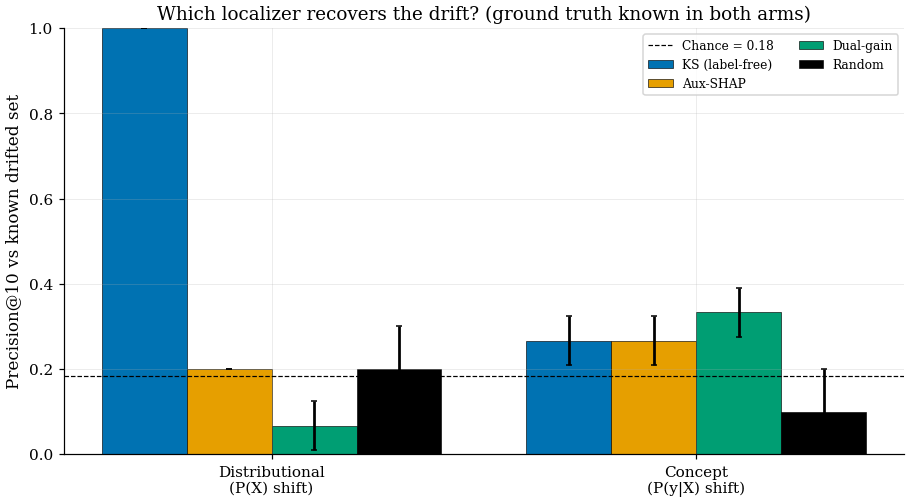

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(ARMS)); w = 0.2
for i, m in enumerate(METHODS):
    means = [pm(arm, m)[0] for arm in ARMS]
    errs = [pm(arm, m)[1] for arm in ARMS]
    ax.bar(x + (i - 1.5) * w, means, w, yerr=errs, capsize=2, color=METHOD_COLOR[m],
           label=METHOD_LABEL[m], edgecolor='black', linewidth=0.4)
ax.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
ax.set_xticks(x); ax.set_xticklabels(['Distributional\n(P(X) shift)', 'Concept\n(P(y|X) shift)'])
ax.set_ylabel(f'Precision@{K_PRIMARY} vs known drifted set'); ax.set_ylim(0, 1.0)
ax.set_title('Which localizer recovers the drift? (ground truth known in both arms)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save_figure(fig, '07e_regime_crossover'); plt.show()


## 9. Pre-registered verdict (D021 / H1)

In [9]:
ks_dist, _ = pm('distributional', 'ks')
shap_dist, _ = pm('distributional', 'aux_shap')
ks_con, _ = pm('concept', 'ks')
shap_con, _ = pm('concept', 'aux_shap')

valid = ks_con <= VALID_KS_CONCEPT_MAX
concept_pole = (shap_con >= SHAP_CONCEPT_MIN) and ((shap_con - ks_con) >= CONCEPT_MARGIN)
dist_pole = (ks_dist >= KS_DIST_MIN) and (ks_dist >= shap_dist - KS_COMPETITIVE_TOL)

if not valid:
    verdict = 'CONSTRUCTION-INVALID'
elif concept_pole and dist_pole:
    verdict = 'H1-SUPPORTED'
elif not concept_pole:
    verdict = 'H1-REFUTED-CONCEPT'
elif not dist_pole:
    verdict = 'DISTRIBUTIONAL-ANOMALY'
else:
    verdict = 'AMBIGUOUS'

print('=' * 64)
print('CONDITIONS VERDICT (D021 / H1)  -- precision@%d, GT known in both arms' % K_PRIMARY)
print('=' * 64)
print(f'  distributional :  KS={ks_dist:.3f}   aux_SHAP={shap_dist:.3f}')
print(f'  concept        :  KS={ks_con:.3f}   aux_SHAP={shap_con:.3f}   (chance {CHANCE:.2f})')
print('-' * 64)
print(f'  construction valid (concept KS <= {VALID_KS_CONCEPT_MAX}) : {valid}')
print(f'  concept pole (SHAP localizes, beats KS by >= {CONCEPT_MARGIN}): {concept_pole}')
print(f'  distributional pole (KS localizes & competitive)    : {dist_pole}')
print(f'\n--> VERDICT: {verdict}')
msg = {
    'H1-SUPPORTED': 'Drift regime is the governing variable: KS suffices under distributional drift, explanations are necessary under concept drift. Conditions thesis earned.',
    'H1-REFUTED-CONCEPT': 'Explanations fail to localize even under concept drift with known GT (likely feature-correlation). Narrow the claim to idealized settings.',
    'DISTRIBUTIONAL-ANOMALY': 'KS did not dominate where expected -- inspect the construction before interpreting.',
    'CONSTRUCTION-INVALID': 'Concept arm leaked input drift (KS not near chance); fix the generator before drawing any conclusion.',
    'AMBIGUOUS': 'Mixed signal; treat as not-confirmed and inspect per-arm numbers.',
}[verdict]
print('   ' + msg)


CONDITIONS VERDICT (D021 / H1)  -- precision@10, GT known in both arms
  distributional :  KS=1.000   aux_SHAP=0.200
  concept        :  KS=0.267   aux_SHAP=0.267   (chance 0.18)
----------------------------------------------------------------
  construction valid (concept KS <= 0.3) : True
  concept pole (SHAP localizes, beats KS by >= 0.2): False
  distributional pole (KS localizes & competitive)    : True

--> VERDICT: H1-REFUTED-CONCEPT
   Explanations fail to localize even under concept drift with known GT (likely feature-correlation). Narrow the claim to idealized settings.


## 10. Record to the project log

In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'gt_size': GT_SIZE, 'k_primary': K_PRIMARY,
    'drift_delta': DRIFT_DELTA, 'chance': CHANCE,
    'distributional': {'ks': ks_dist, 'aux_shap': shap_dist},
    'concept': {'ks': ks_con, 'aux_shap': shap_con},
    'diagnostics': diag_df.groupby('arm')[['balance_post', 'aux_recall', 'ks_max']].mean().round(3).to_dict(),
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F009',
    title='Drift-regime conditions test on real features with known ground truth (notebook 07e / ARM B)',
    context='03_phase1_cicids/07e_drift_regime_testbed',
    what_we_did=(
        'Built a semi-synthetic 2x2 crossover on real CICIDS feature vectors with a '
        'synthetic label rule, so the drifted features are known in both arms. '
        'Distributional arm shifts input marginals (P(X) moves, rule fixed); concept '
        'arm swaps relevant features (P(X) stable, P(y|X) moves). Measured precision@10 '
        'of KS (label-free) and aux-SHAP at recovering the known drifted set, with '
        'construction-validity checks. Pre-registered H1 + falsifiers (D021).'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Precision@10 -- distributional: KS=' + f'{ks_dist:.3f}, '
        f'aux_SHAP={shap_dist:.3f}; concept: KS={ks_con:.3f}, aux_SHAP={shap_con:.3f} '
        f'(chance {CHANCE:.2f}). Construction valid (concept P(X) stable): {valid}.'
    ),
    why_it_matters=(
        'This is the confound-controlled test of the conditions thesis. With ground '
        'truth held known in both arms, a KS-collapse-under-concept-drift / SHAP-works '
        'crossover attributes the difference to drift TYPE, not ground-truth availability '
        '-- which is what licenses the "conditions of validity" framing for the thesis.'
    ),
)
print('F009 logged. Record the conditions call in a hand journal entry.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07e_regime_testbed.json
[FINDING LOGGED] F009: Drift-regime conditions test on real features with known ground truth (notebook 07e / ARM B)
F009 logged. Record the conditions call in a hand journal entry.


## 11. What this settles

- **H1-SUPPORTED** -> with ground truth known throughout, KS suffices under
  distributional drift and explanations are necessary under concept drift. Drift
  *type* (not ground-truth availability) is the governing variable. The
  conditions-of-validity thesis is earned, and the regime map (`drift_regime_map.md`)
  is now backed by a confound-controlled experiment. Proceed to breadth: replicate
  the distributional pole on UNSW + XGBoost, and the concept pole across more
  rule/feature configurations and a second model class.
- **H1-REFUTED-CONCEPT** -> even with known ground truth, SHAP cannot cleanly
  localize a relevance swap on correlated real features (the importance-instability
  from 07c/07d biting again). The honest claim narrows: explanation localization
  works only in idealized, low-correlation synthetic settings, not on realistic
  feature geometry. Strong, if deflating, and still publishable.
- **CONSTRUCTION-INVALID** -> the concept arm leaked input drift; fix the generator
  (check the relevance swap truly holds P(X) fixed) and re-run before concluding.
- **DISTRIBUTIONAL-ANOMALY / AMBIGUOUS** -> inspect per-arm numbers; do not over-read.

Record the call by hand:

```python
add_journal_entry(
    title='Notebook 07e / ARM B conditions verdict',
    body='...the 2x2 numbers, construction validity, the verdict, and whether drift regime is confirmed as the governing variable...',
)
```
